In [ ]:
import kagglehub
import os
path = kagglehub.dataset_download("bmadushanirodrigo/fracture-multi-region-x-ray-data")
print("Dataset path:", path)
for root, dirs, files in os.walk(path):
    print(root)

Using Colab cache for faster access to the 'fracture-multi-region-x-ray-data' dataset.
Dataset path: /kaggle/input/fracture-multi-region-x-ray-data
/kaggle/input/fracture-multi-region-x-ray-data
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/not fractured
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/fractured
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test
/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bon

In [ ]:
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torchvision.transforms as transforms


train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.RandomRotation(degrees=(3, 13)),
    transforms.RandomResizedCrop(size=128, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomResizedCrop(size=128, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

training_data = datasets.ImageFolder(
    # root=f'/root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train',
    root=f'/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train', # root for kelly
    transform=train_transform
)

test_data = datasets.ImageFolder(
    # root=f'/root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test',
    root=f'/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test',
    transform=test_transform
)

val_data = datasets.ImageFolder(
    # root=f'/root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val',
    root=f'/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val',
    transform=test_transform
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Inputs sample - image size: torch.Size([3, 128, 128])
Label: 1 

Inputs sample - min,max,mean,std: -1.0 0.615686297416687 -0.7340097427368164 0.3463767170906067
Inputs sample normalized - min,max,mean,std: -0.7679218649864197 3.896613121032715 -7.140139590688932e-09 1.0


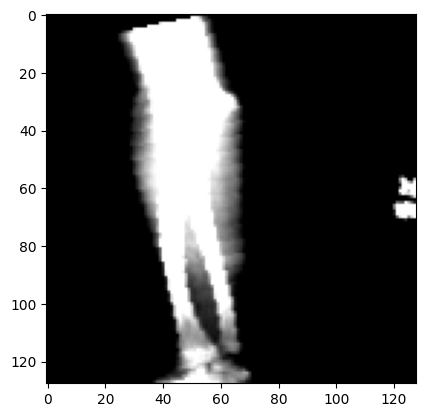

In [ ]:
# let us print some data:

categories = ['fractured', 'not fractured']

# select a random sample from the training set
sample_num = random.randint(0, len(training_data) - 1) # select a random sample
# print(training_data[sample_num])
print('Inputs sample - image size:', training_data[sample_num][0].shape)
print('Label:', training_data[sample_num][1], '\n')

import matplotlib.pyplot as plt

ima = training_data[sample_num][0]
print('Inputs sample - min,max,mean,std:', ima.min().item(), ima.max().item(), ima.mean().item(), ima.std().item())
ima = (ima - ima.mean())/ ima.std()
print('Inputs sample normalized - min,max,mean,std:', ima.min().item(), ima.max().item(), ima.mean().item(), ima.std().item())
iman = ima.permute(1, 2, 0) # needed to be able to plot
plt.imshow(iman)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 29 * 29, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_loop(dataloader, model, loss_fn, optimizer, train_losses, train_accuracies):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, correct = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    train_losses.append(train_loss / num_batches)
    train_accuracies.append(correct / size)


def test_loop(dataloader, model, loss_fn, val_losses, val_accuracies):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size

    val_losses.append(test_loss)
    val_accuracies.append(correct)

    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
# training!
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

model = Net()

train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True)

loss_fn = nn.CrossEntropyLoss() # used for categorization
learning_rate = 1e-3
# note: optimizer is Adam: one of the best optimizers to date
# it can infer learning rate and all hyper-parameters automatically
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer, train_losses, train_accuracies)
    test_loop(test_dataloader, model, loss_fn, val_losses, val_accuracies)
print("Done!")

Epoch 1
-------------------------------
loss: 2.247431  [   32/ 9246]
loss: 0.611904  [ 3232/ 9246]
loss: 0.523669  [ 6432/ 9246]
Test Error: 
 Accuracy: 67.4%, Avg loss: 0.617676 

Epoch 2
-------------------------------
loss: 0.551850  [   32/ 9246]
loss: 0.374179  [ 3232/ 9246]
loss: 0.446373  [ 6432/ 9246]
Test Error: 
 Accuracy: 73.5%, Avg loss: 0.524267 

Epoch 3
-------------------------------
loss: 0.338348  [   32/ 9246]
loss: 0.431071  [ 3232/ 9246]
loss: 0.240888  [ 6432/ 9246]
Test Error: 
 Accuracy: 80.4%, Avg loss: 0.457845 

Epoch 4
-------------------------------
loss: 0.383536  [   32/ 9246]
loss: 0.352133  [ 3232/ 9246]
loss: 0.429267  [ 6432/ 9246]
Test Error: 
 Accuracy: 83.6%, Avg loss: 0.380406 

Epoch 5
-------------------------------
loss: 0.084924  [   32/ 9246]
loss: 0.167660  [ 3232/ 9246]
loss: 0.184467  [ 6432/ 9246]
Test Error: 
 Accuracy: 86.6%, Avg loss: 0.276706 

Epoch 6
-------------------------------
loss: 0.190796  [   32/ 9246]
loss: 0.037131  [ 32

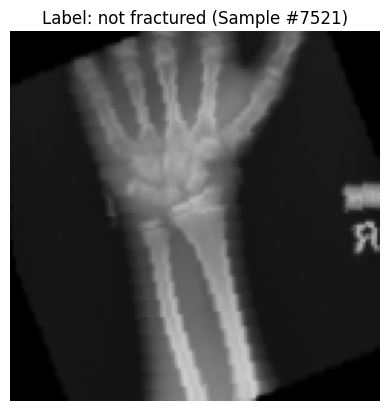

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

sample_num = random.randint(0, len(training_data) - 1)
image, label = training_data[sample_num]


mean = torch.tensor([0.5, 0.5, 0.5]) # Use the same values from your train_transform
std = torch.tensor([0.5, 0.5, 0.5])

image_vis = image.permute(1, 2, 0) # Change from (C, H, W) to (H, W, C) for matplotlib
image_vis = image_vis * std + mean
image_vis = torch.clamp(image_vis, 0, 1) # Ensure values are strictly between 0 and 1

plt.imshow(image_vis)
plt.title(f"Label: {categories[label]} (Sample #{sample_num})")
plt.axis('off')
plt.show()


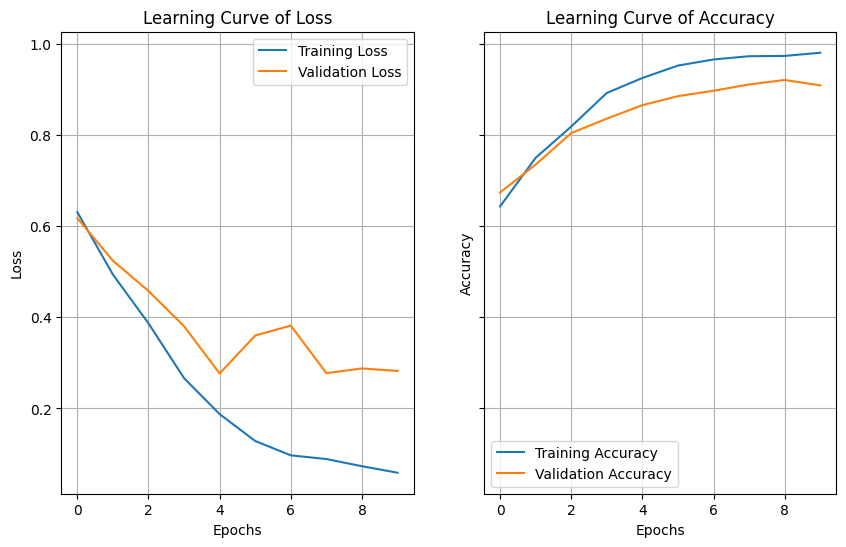

In [ ]:
# learning curves

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True)

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve of Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Learning Curve of Accuracy')
plt.legend()
plt.grid(True)

plt.show()
